# Time-Series EDA

Phase 2 notebook for trend checks, missing values, and injected anomaly visibility.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/raw')
if not DATA_DIR.exists():
    DATA_DIR = Path('data/raw')

paths = sorted(DATA_DIR.glob('timeseries_*.csv'))
frames = [pd.read_csv(path, parse_dates=['date']) for path in paths]
timeseries = pd.concat(frames, ignore_index=True)
timeseries.head()

,company_name,date,revenue,active_users,signups,is_injected_anomaly
0,GreenLeaf SaaS,2025-01-01,13664.85,787,38,False
1,GreenLeaf SaaS,2025-01-02,15622.73,981,44,False
2,GreenLeaf SaaS,2025-01-03,15075.32,959,48,False
3,GreenLeaf SaaS,2025-01-04,13799.59,650,27,False
4,GreenLeaf SaaS,2025-01-05,11446.44,573,16,False


In [2]:
print('Shape:', timeseries.shape)
display(timeseries.info())
display(timeseries.isna().sum())
display(timeseries.groupby('company_name')['date'].agg(['min', 'max', 'count']))

Shape: (1095, 6)
<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   company_name         1095 non-null   str           
 1   date                 1095 non-null   datetime64[us]
 2   revenue              1095 non-null   float64       
 3   active_users         1095 non-null   int64         
 4   signups              1095 non-null   int64         
 5   is_injected_anomaly  1095 non-null   bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 57.5 KB


None

company_name           0
date                   0
revenue                0
active_users           0
signups                0
is_injected_anomaly    0
dtype: int64

,min,max,count
company_name,,,
GreenLeaf SaaS,2025-01-01,2025-12-31,365
MixedCo,2025-01-01,2025-12-31,365
RedFlag Analytics,2025-01-01,2025-12-31,365


In [3]:
summary = timeseries.groupby('company_name').agg(
    injected_anomalies=('is_injected_anomaly', 'sum'),
    mean_revenue=('revenue', 'mean'),
    min_revenue=('revenue', 'min'),
    max_revenue=('revenue', 'max'),
    mean_active_users=('active_users', 'mean'),
    mean_signups=('signups', 'mean'),
).round(2)
display(summary)

,injected_anomalies,mean_revenue,min_revenue,max_revenue,mean_active_users,mean_signups
company_name,,,,,,
GreenLeaf SaaS,0,19087.80,11446.44,31318.31,1056.87,47.37
MixedCo,1,10193.16,7774.29,12763.39,566.36,25.17
RedFlag Analytics,4,9369.16,4898.83,17737.81,523.23,23.58


In [4]:
for company, company_df in timeseries.groupby('company_name'):
    company_df = company_df.sort_values('date')
    first_revenue = company_df['revenue'].iloc[0]
    last_revenue = company_df['revenue'].iloc[-1]
    revenue_change = (last_revenue / first_revenue - 1) * 100
    print(f'{company}: {revenue_change:.2f}% revenue change')

GreenLeaf SaaS: 92.80% revenue change
MixedCo: 10.48% revenue change
RedFlag Analytics: -42.34% revenue change


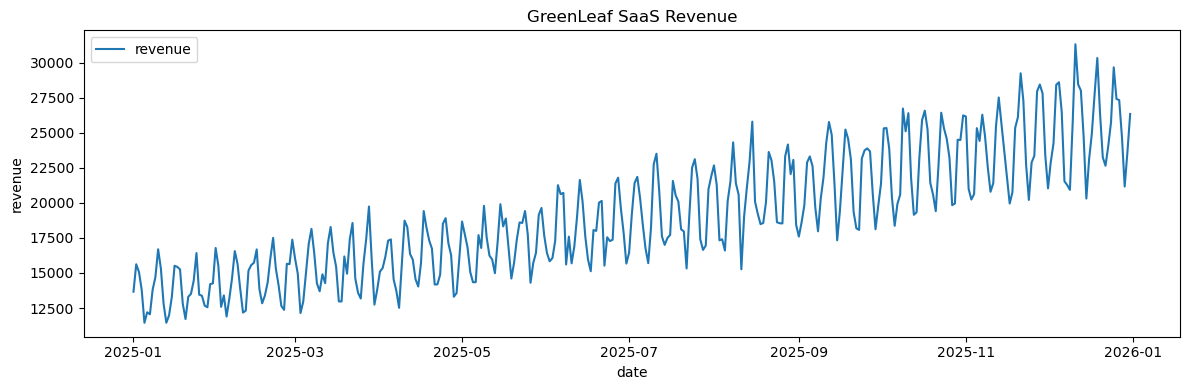

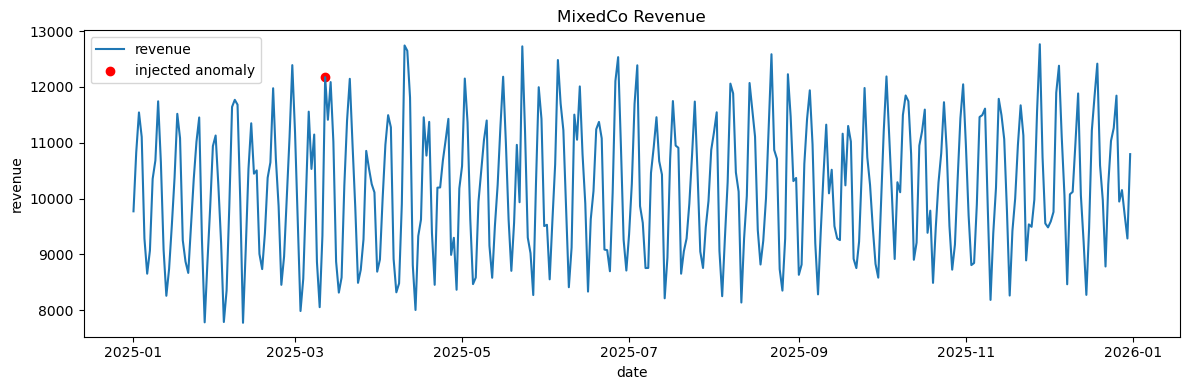

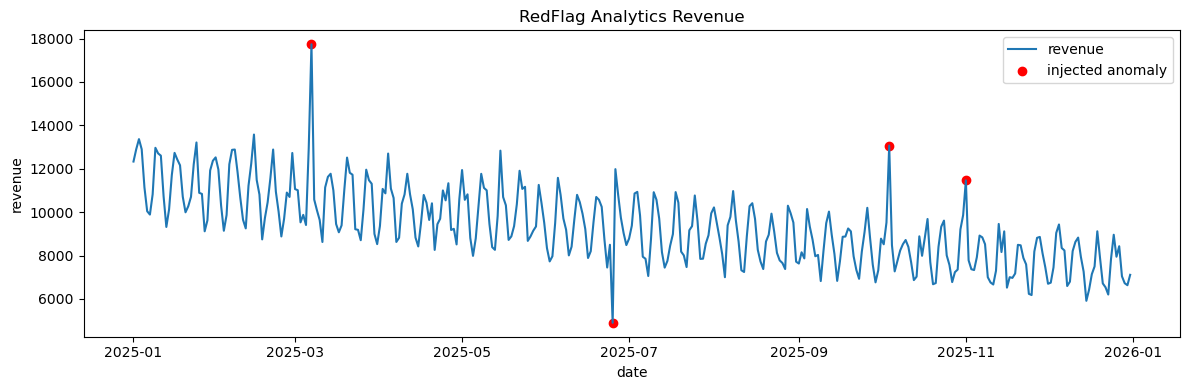

In [5]:
for company, company_df in timeseries.groupby('company_name'):
    company_df = company_df.sort_values('date')
    anomalies = company_df[company_df['is_injected_anomaly'] == 1]

    plt.figure(figsize=(12, 4))
    plt.plot(company_df['date'], company_df['revenue'], label='revenue')
    if not anomalies.empty:
        plt.scatter(anomalies['date'], anomalies['revenue'], color='red', label='injected anomaly')
    plt.title(f'{company} Revenue')
    plt.xlabel('date')
    plt.ylabel('revenue')
    plt.legend()
    plt.tight_layout()
    plt.show()

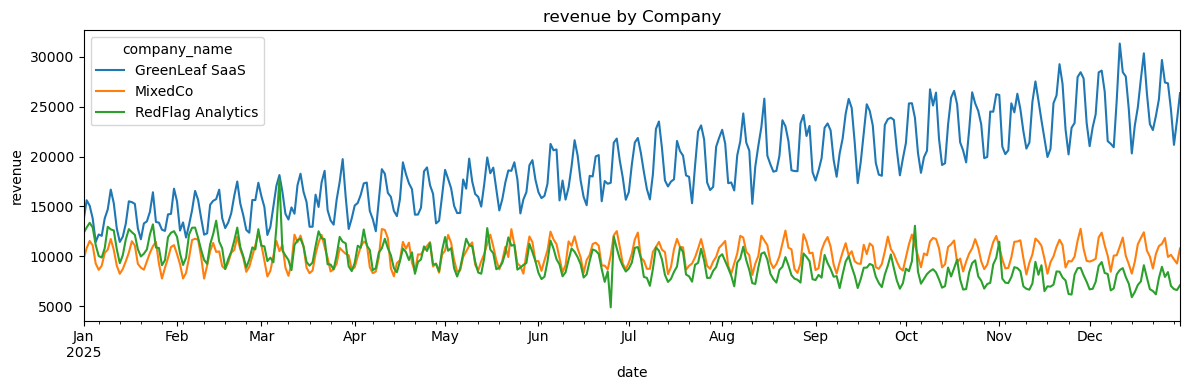

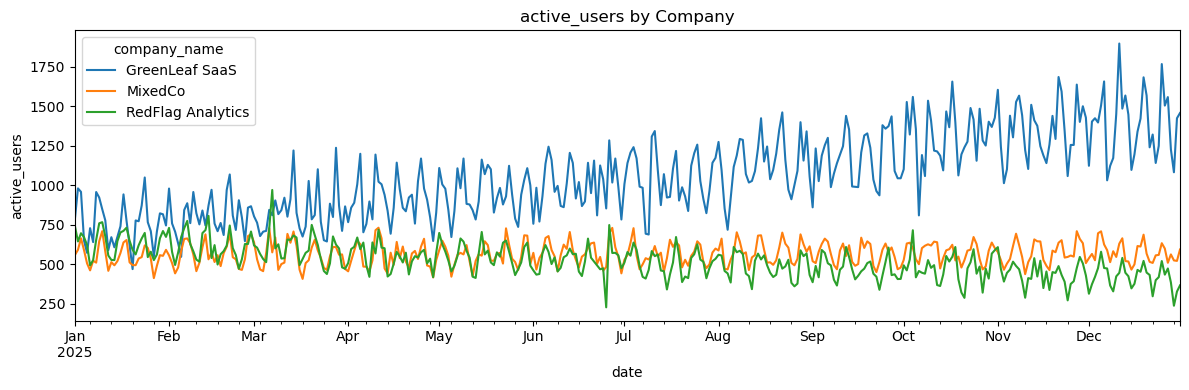

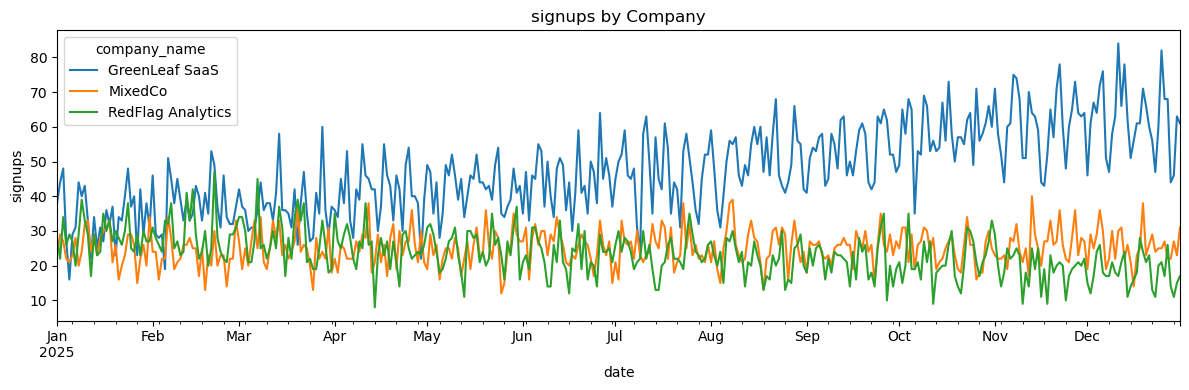

In [6]:
for metric in ['revenue', 'active_users', 'signups']:
    pivot = timeseries.pivot(index='date', columns='company_name', values=metric)
    pivot.plot(figsize=(12, 4), title=f'{metric} by Company')
    plt.xlabel('date')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()